# 공유 자전거 수요 예측 회귀분석

### UCI Bike Sharing Dataset 기반 일별 대여 수요 분석

---

| 구분 | 내용 |
|:---|:---|
| **소속** | 7반 6조 |
| **팀원** | 김광현 · 임유리 · 임채현 |
| **분석 방법** | 다중선형회귀 |
| **종속변수** | 일별 총대여량 (`cnt`) |

본 분석에서는 날씨, 계절, 근무일 등의 환경 요인을 이용하여 일별 공유 자전거 대여량을 예측한다. 또한 대여량 변화의 주요 요인을 파악하여 자전거 재배치와 운영 인력 계획에 활용할 수 있는 인사이트를 도출한다.

---

# 1단계. 문제 정의 및 변수 설계

## 1.1 분석 목적

본 분석은 날씨, 계절, 근무일 등의 환경 요인을 이용하여 일별 공유 자전거 대여량을 예측하는 것을 목적으로 한다.

또한 대여량 변화에 영향을 미치는 주요 요인을 파악하여 자전거 배치와 운영 인력 계획에 활용할 수 있는 인사이트를 도출하고자 한다.

종속변수는 일별 총대여량인 `cnt`로 설정하였다.

## 1.2 변수 선택 및 선택 근거

종속변수는 하루 동안 발생한 전체 자전거 대여량을 의미하는 `cnt`로 설정하였다.

독립변수는 자전거 대여 수요에 영향을 줄 수 있는 기상 조건, 계절적 요인, 운영일 특성 및 시간 효과를 고려하여 선정하였다.

### 사용할 독립변수

- `temp`: 정규화된 기온으로, 기온은 야외활동의 편의성과 직접적으로 관련되므로 대여 수요를 설명하는 연속형 변수로 선정하였다.
- `hum`: 정규화된 습도로, 높은 습도는 자전거 이용의 쾌적성을 낮출 수 있으므로 연속형 변수로 선정하였다.
- `windspeed`: 정규화된 풍속으로, 강한 바람은 자전거 주행을 어렵게 할 수 있으므로 연속형 변수로 선정하였다.
- `season`: 계절별 기후와 야외활동 패턴에 따른 대여량 차이를 반영하기 위해 범주형 변수로 선정하였다.
- `weathersit`: 맑음, 흐림, 비·눈 등 날씨 상태에 따른 대여량 차이를 반영하기 위해 범주형 변수로 선정하였다.
- `holiday`: 공휴일에는 통근 및 여가 목적의 이용 패턴이 달라질 수 있으므로 범주형 변수로 선정하였다.
- `workingday`: 근무일과 비근무일의 통근 수요 차이를 반영하기 위해 범주형 변수로 선정하였다.
- `yr`: 환경 요인은 아니지만, 2011년과 2012년 사이의 서비스 성장 및 시간 흐름에 따른 대여량 차이를 통제하기 위해 범주형 변수로 선정하였다.

`temp`, `hum`, `windspeed`는 측정값의 크기와 변화량에 의미가 있으므로 연속형 변수로 처리하였다.

`season`, `weathersit`, `holiday`, `workingday`, `yr`는 숫자로 저장되어 있지만 각 숫자가 특정 집단을 나타내므로 범주형 변수로 처리하였다.

## 1.3 제외 변수와 제외 이유

- `instant`는 각 관측치를 구분하기 위한 행 식별 번호이며, 그 자체로 대여 수요에 영향을 주는 의미 있는 설명변수가 아니므로 제외하였다.
- `dteday`는 개별 날짜를 나타내는 변수이며, 날짜에 포함된 연도와 계절 정보는 `yr`와 `season`으로 반영하였다. 이번 분석에서는 장기적인 시계열 추세보다 환경 요인이 대여량에 미치는 영향에 초점을 맞추므로 제외하였다.
- `atemp`는 체감온도로 `temp`와 매우 유사한 기온 정보를 포함한다. 두 변수를 동시에 사용하면 변수 중복과 다중공선성이 발생할 가능성이 있으므로, 해석이 더 직접적인 `temp`를 사용하고 `atemp`는 제외하였다.
- `mnth`는 월별 이용 패턴을 나타낼 수 있지만 `season`과 계절 관련 정보가 일부 중복될 수 있다. 이번 분석에서는 월별 세부 변동보다 계절별 대여 수요의 차이에 초점을 맞추고 모델을 간결하게 유지하기 위해 `mnth`를 제외하였다. 다만 이로 인해 동일한 계절 내 월별 수요 차이를 충분히 반영하지 못할 수 있다.
- `weekday`는 요일별 이용 차이를 나타내는 변수이지만, 근무일 여부를 나타내는 `workingday`와 일부 정보가 중복된다. 이번 분석에서는 요일별 세부 차이보다 근무일과 비근무일의 수요 차이에 초점을 맞추고 모델을 간결하게 유지하기 위해 `weekday`를 제외하였다. 다만 이로 인해 평일 내 요일별 수요 차이를 충분히 반영하지 못할 수 있다.

## 1.4 `casual`, `registered`를 독립변수로 사용할 수 없는 이유

- `casual`과 `registered`의 합은 종속변수인 `cnt`와 정확히 일치한다. 즉, `cnt = casual + registered`의 관계가 성립한다.
- 두 변수를 독립변수로 사용하면 예측하려는 종속변수의 구성 정보를 모델에 미리 제공하게 되어 데이터 누수가 발생한다.
- 이 경우 실제 예측 상황에서는 얻을 수 없는 정보를 사용하게 되며, 모델의 성능이 비정상적으로 높게 평가될 수 있으므로 `casual`과 `registered`를 독립변수에서 제외하였다.

# 2단계. 데이터 탐색(EDA) 및 전처리

## 2.1 데이터 불러오기 및 기본 확인

UCI Bike Sharing Dataset의 일별 데이터인 `day.csv`를 사용하였다.

데이터를 불러온 후 데이터의 크기와 처음 5개 행을 확인한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 기본 스타일 지정
sns.set_theme(style="whitegrid")

# 데이터 불러오기
df = pd.read_csv("https://raw.githubusercontent.com/oriolramospuig/bikeSharingCSV/main/day.csv")

# 데이터 크기와 처음 5개 행 확인
print("데이터 크기:", df.shape)
display(df.head())

데이터 크기: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## 2.2 데이터 품질 확인

모델을 구축하기 전에 변수의 자료형, 결측치 및 중복 행을 확인한다.

결측치가 존재하면 제거하거나 대체하는 과정이 필요하며, 동일한 데이터가 중복된 경우 분석 결과에 영향을 줄 수 있으므로 이를 점검한다.

In [2]:
# 변수 자료형과 데이터 구조 확인
df.info()

# 변수별 결측치 확인
print("\n변수별 결측치")
display(df.isnull().sum().to_frame("결측치 수"))

# 중복 행 확인
print("중복 행 수:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

변수별 결측치


,결측치 수
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


중복 행 수: 0


## 2.3 데이터 확인 결과

데이터는 총 731개 행과 16개 변수로 구성되어 있다.

변수별 결측치를 확인한 결과 모든 변수의 결측치가 0건이었으며, 중복 행도 발견되지 않았다. 따라서 별도의 결측치 처리와 중복 데이터 제거는 수행하지 않았다.

종속변수인 `cnt`는 정수형으로 저장되어 있다. `temp`, `atemp`, `hum`, `windspeed`는 실수형이며, `season`, `weathersit`, `holiday`, `workingday`, `yr`는 숫자로 저장되어 있지만 각 숫자가 특정 집단을 나타내므로 의미상 범주형 변수에 해당한다.

## 2.4 데이터 누수 확인 및 분석 데이터 구성

`cnt`가 `casual`과 `registered`의 합으로 구성되는지 직접 확인한 후, 분석에 사용할 변수만 선택하여 분석용 데이터를 구성한다.

In [3]:
# cnt가 casual과 registered의 합으로 구성되는지 확인
cnt_check = (df["cnt"] == df["casual"] + df["registered"]).all()
print("cnt = casual + registered가 모든 행에서 성립하는가?", cnt_check)

# 분석에 사용할 변수 지정
selected_columns = [
    "temp",
    "hum",
    "windspeed",
    "season",
    "weathersit",
    "holiday",
    "workingday",
    "yr",
    "cnt"
]

analysis_df = df[selected_columns].copy()

print("분석용 데이터 크기:", analysis_df.shape)
display(analysis_df.head())

cnt = casual + registered가 모든 행에서 성립하는가? True
분석용 데이터 크기: (731, 9)


,temp,hum,windspeed,season,weathersit,holiday,workingday,yr,cnt
0,0.344167,0.805833,0.160446,1,2,0,0,0,985
1,0.363478,0.696087,0.248539,1,2,0,0,0,801
2,0.196364,0.437273,0.248309,1,1,0,1,0,1349
3,0.200000,0.590435,0.160296,1,1,0,1,0,1562
4,0.226957,0.436957,0.186900,1,1,0,1,0,1600


### 분석 데이터 구성 결과

확인 결과 모든 행에서 `cnt = casual + registered` 관계가 성립하였다.

따라서 다시 한 번 `casual`과 `registered`를 독립변수로 사용하면 종속변수의 정보를 모델이 미리 알게 되는 데이터 누수가 발생하므로 두 변수를 제외하였다.

최종적으로 종속변수 `cnt`와 8개의 독립변수를 포함한 총 9개 변수로 분석용 데이터를 구성하였다.

## 2.5 기술통계량 확인

모델을 구축하기 전에 분석에 사용할 변수의 평균, 표준편차, 최솟값, 최댓값 및 분위수를 확인한다.

In [4]:
# 분석 변수의 기술통계량 확인
display(analysis_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
temp,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667
hum,731.0,0.627894,0.142429,0.000000,0.520000,0.626667,0.730209,0.972500
windspeed,731.0,0.190486,0.077498,0.022392,0.134950,0.180975,0.233214,0.507463
season,731.0,2.496580,1.110807,1.000000,2.000000,3.000000,3.000000,4.000000
weathersit,731.0,1.395349,0.544894,1.000000,1.000000,1.000000,2.000000,3.000000
holiday,731.0,0.028728,0.167155,0.000000,0.000000,0.000000,0.000000,1.000000
workingday,731.0,0.683995,0.465233,0.000000,0.000000,1.000000,1.000000,1.000000
yr,731.0,0.500684,0.500342,0.000000,0.000000,1.000000,1.000000,1.000000
cnt,731.0,4504.348837,1937.211452,22.000000,3152.000000,4548.000000,5956.000000,8714.000000


## 2.6 일별 대여량 분포 확인

종속변수 `cnt`의 히스토그램과 상자그림을 이용하여 일별 대여량의 분포와 이상치 여부를 확인한다.

평균 대여량: 4504.35
중앙값: 4548.0
최소 대여량: 22
최대 대여량: 8714
왜도: -0.047


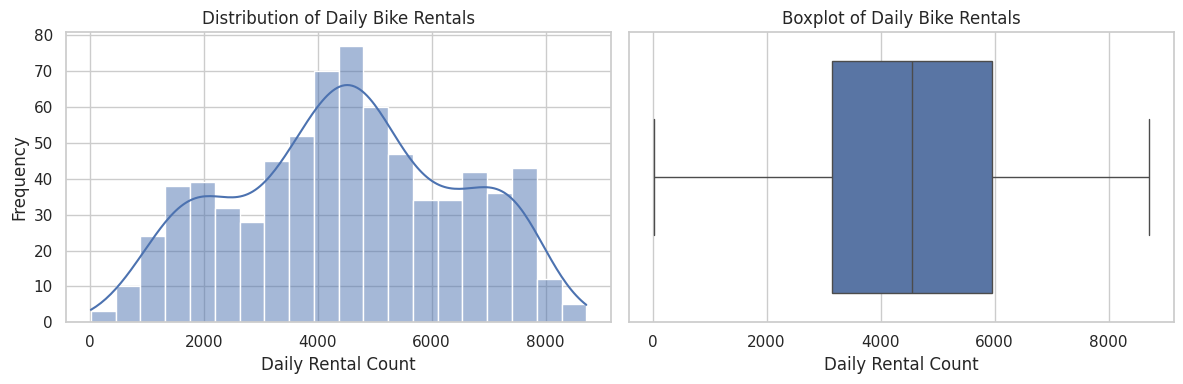

In [5]:
# 일별 대여량의 주요 통계량 출력
print("평균 대여량:", round(analysis_df["cnt"].mean(), 2))
print("중앙값:", round(analysis_df["cnt"].median(), 2))
print("최소 대여량:", analysis_df["cnt"].min())
print("최대 대여량:", analysis_df["cnt"].max())
print("왜도:", round(analysis_df["cnt"].skew(), 3))

# 히스토그램과 상자그림
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=analysis_df,
    x="cnt",
    bins=20,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Daily Bike Rentals")
axes[0].set_xlabel("Daily Rental Count")
axes[0].set_ylabel("Frequency")

sns.boxplot(
    data=analysis_df,
    x="cnt",
    ax=axes[1]
)
axes[1].set_title("Boxplot of Daily Bike Rentals")
axes[1].set_xlabel("Daily Rental Count")

plt.tight_layout()
plt.show()

## 2.7 대여량 분포 분석 결과

일별 평균 대여량은 약 4,504대이며, 중앙값은 4,548대로 나타났다. 최소 대여량은 22대이고 최대 대여량은 8,714대이다.

평균과 중앙값의 차이가 크지 않고 왜도가 0에 가까워, 일별 대여량은 한쪽으로 심하게 치우치지 않은 분포를 보였다.

상자그림을 확인한 결과 종속변수에 극단적인 이상치는 두드러지게 나타나지 않았다. 따라서 이번 분석에서는 `cnt`에 대한 별도의 이상치 제거 또는 로그 변환을 수행하지 않는다.

## 2.8 계절 및 날씨별 평균 대여량

계절과 날씨 상태에 따라 일별 평균 자전거 대여량에 차이가 있는지 확인한다.

`season`과 `weathersit`은 숫자로 저장되어 있으므로 그래프를 쉽게 해석할 수 있도록 각 숫자를 실제 범주명으로 변환하여 시각화한다.

In [6]:
# 범주 이름 지정
season_names = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

weather_names = {
    1: "Clear",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow"
}

# 시각화를 위한 데이터 복사
eda_df = analysis_df.copy()

# 숫자로 된 범주를 이름으로 변환
eda_df["season_name"] = eda_df["season"].map(season_names)
eda_df["weather_name"] = eda_df["weathersit"].map(weather_names)

# 계절별·날씨별 평균 대여량 계산
season_mean = (
    eda_df.groupby("season_name")["cnt"]
    .mean()
    .reindex(["Spring", "Summer", "Fall", "Winter"])
)

weather_mean = (
    eda_df.groupby("weather_name")["cnt"]
    .mean()
    .reindex(["Clear", "Mist/Cloudy", "Light Rain/Snow", "Heavy Rain/Snow"])
)

print("계절별 평균 대여량")
display(season_mean.to_frame("평균 대여량").round(2))

print("날씨별 평균 대여량")
display(weather_mean.to_frame("평균 대여량").round(2))

계절별 평균 대여량


,평균 대여량
season_name,
Spring,2604.13
Summer,4992.33
Fall,5644.30
Winter,4728.16


날씨별 평균 대여량


,평균 대여량
weather_name,
Clear,4876.79
Mist/Cloudy,4035.86
Light Rain/Snow,1803.29
Heavy Rain/Snow,NaN


#### Heavy Rain/Snow에 해당하는 데이터가 존재하지 않아(NaN) 그래프에서 제외

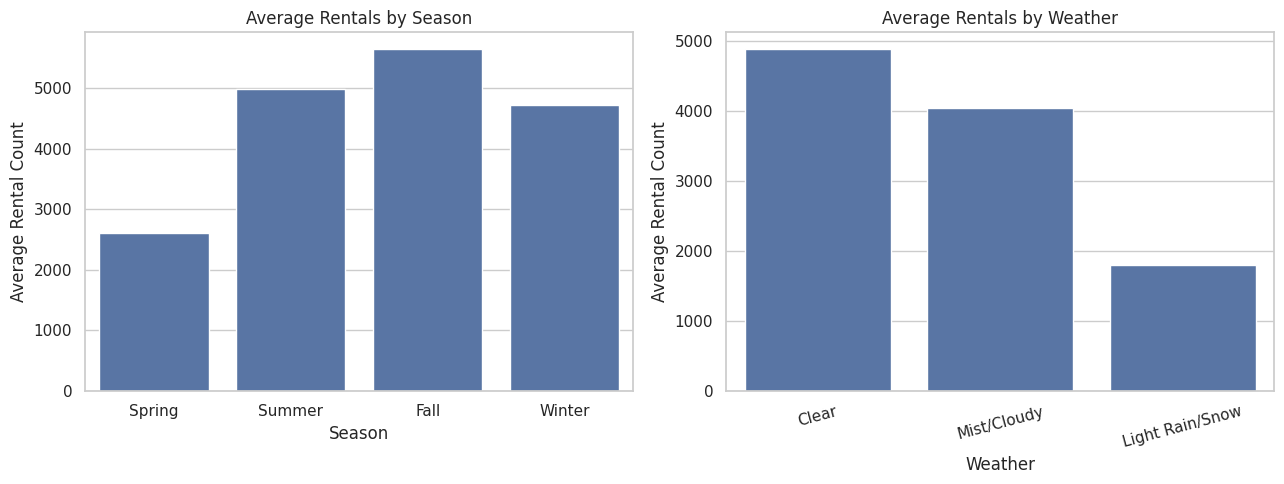

In [7]:
# 계절별·날씨별 평균 대여량 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=eda_df,
    x="season_name",
    y="cnt",
    order=["Spring", "Summer", "Fall", "Winter"],
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Average Rentals by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Average Rental Count")

sns.barplot(
    data=eda_df,
    x="weather_name",
    y="cnt",
    order=["Clear", "Mist/Cloudy", "Light Rain/Snow"],
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Average Rentals by Weather")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("Average Rental Count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 2.9 계절 및 날씨별 분석 결과

계절별 평균 대여량은 가을이 약 5,644대로 가장 높았고, 여름이 약 4,992대, 겨울이 약 4,728대, 봄이 약 2,604대 순으로 나타났다.

날씨가 맑은 날의 평균 대여량은 약 4,877대였으며, 안개가 끼거나 흐린 날에는 약 4,036대, 약한 비나 눈이 오는 날에는 약 1,803대로 감소하였다.

이를 통해 계절과 날씨 상태가 자전거 대여 수요와 관련이 있으며, 특히 비나 눈이 오는 날에는 대여량이 크게 감소하는 경향이 있음을 확인하였다.

## 2.10 기온과 대여량의 관계

연속형 변수인 기온 `temp`와 일별 대여량 `cnt`의 관계를 산점도와 상관계수를 이용하여 확인한다.

산점도에는 전체적인 관계를 확인하기 위해 단순 회귀선을 함께 표시한다.

기온과 대여량의 상관계수: 0.627


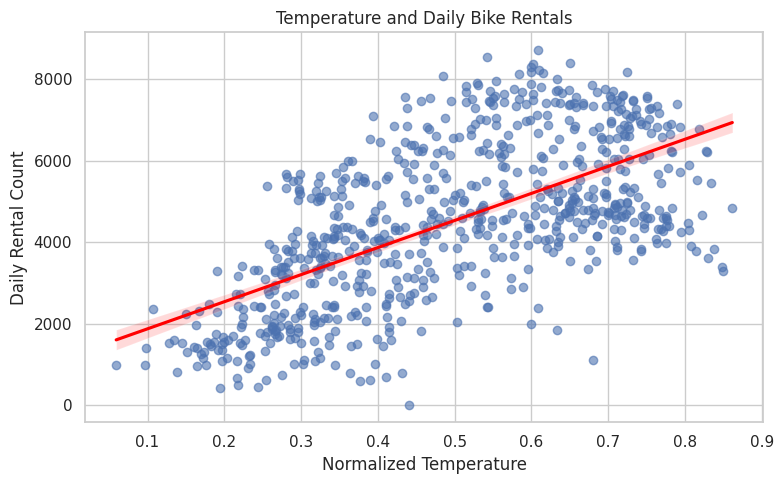

In [8]:
# 기온과 대여량의 상관계수
temp_corr = analysis_df["temp"].corr(analysis_df["cnt"])
print("기온과 대여량의 상관계수:", round(temp_corr, 3))

# 기온과 대여량 산점도
plt.figure(figsize=(8, 5))

sns.regplot(
    data=analysis_df,
    x="temp",
    y="cnt",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Temperature and Daily Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Daily Rental Count")
plt.tight_layout()
plt.show()

## 2.11 기온과 대여량 분석 결과

기온과 일별 대여량의 상관계수는 약 0.628로 나타나 비교적 뚜렷한 양의 상관관계가 확인되었다.

산점도에서도 기온이 상승할수록 일별 대여량이 대체로 증가하는 경향을 확인할 수 있었다. 따라서 `temp`는 자전거 대여량을 예측하는 데 유용한 변수로 판단하였다.

다만 동일한 기온에서도 대여량의 차이가 크게 나타나는 구간이 있으므로, 기온만으로 대여량 전체를 설명하기는 어렵다. 계절, 날씨, 습도 및 근무일 등의 변수를 함께 고려할 필요가 있다.

## 2.12 숫자형 변수의 상관관계

기온, 습도, 풍속과 일별 대여량 사이의 선형적인 관계를 확인하기 위해 상관계수 행렬을 계산하고 히트맵으로 시각화한다.

상관계수는 -1에서 1 사이의 값을 가지며, 1에 가까울수록 강한 양의 관계, -1에 가까울수록 강한 음의 관계가 있음을 의미한다.

,temp,hum,windspeed,cnt
temp,1.000,0.127,-0.158,0.627
hum,0.127,1.000,-0.248,-0.101
windspeed,-0.158,-0.248,1.000,-0.235
cnt,0.627,-0.101,-0.235,1.000


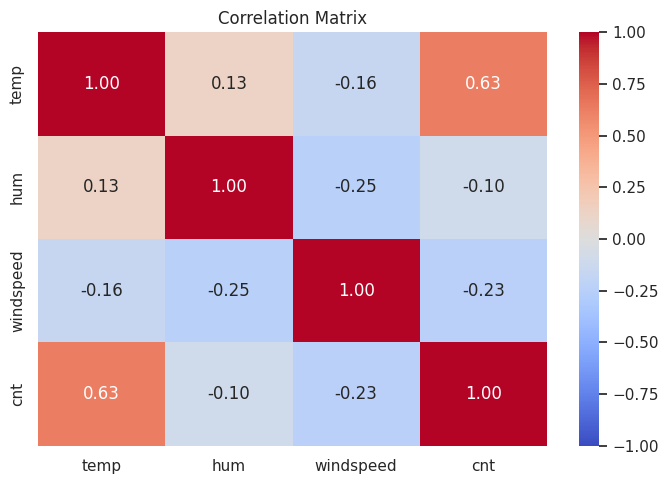

In [9]:
# 상관관계를 확인할 숫자형 변수
continuous_columns = [
    "temp",
    "hum",
    "windspeed",
    "cnt"
]

# 상관계수 행렬 계산
correlation_matrix = analysis_df[continuous_columns].corr()
display(correlation_matrix.round(3))

# 상관계수 히트맵
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 2.13 상관관계 분석 결과

기온 `temp`와 일별 대여량 `cnt`의 상관계수는 약 0.63으로 나타나 비교적 뚜렷한 양의 관계가 확인되었다. 즉, 기온이 높을수록 대여량이 증가하는 경향이 있다.

풍속 `windspeed`와 대여량의 상관계수는 약 -0.23으로 나타나 약한 음의 관계를 보였다. 습도 `hum`과 대여량의 상관계수는 약 -0.10으로 선형관계가 크지 않았다.

다만 상관계수는 두 변수 사이의 개별적인 관계만 보여주므로, 다른 변수의 영향을 함께 고려하기 위해 이후 다중선형회귀 모델을 구축한다.

## 2.14 범주형 변수 전처리

`season`, `weathersit`, `holiday`, `workingday`, `yr`는 숫자로 저장되어 있지만 각 숫자는 수치적인 크기보다 서로 다른 집단을 나타낸다.

이러한 변수를 정수 상태 그대로 회귀모델에 입력하면 모델이 범주 사이에 일정한 순서와 간격이 있다고 잘못 해석할 수 있다. 예를 들어 `season`을 정수로 사용하면 계절 코드가 1 증가할 때마다 대여량이 일정하게 변한다고 가정하지만, 실제 계절별 대여량은 이러한 선형적인 관계를 보이지 않는다.

따라서 범주 사이에 임의의 순서나 간격을 가정하지 않고 각 범주의 효과를 개별적으로 추정하기 위해 다음 범주형 변수에 원-핫 인코딩을 적용하였다.

- `season`
- `weathersit`
- `holiday`
- `workingday`
- `yr`

원-핫 인코딩 과정에서는 `drop_first=True`를 적용하여 각 범주형 변수의 첫 번째 범주를 기준 범주로 제외하였다. 이는 모든 더미변수와 절편 사이에 완전한 선형관계가 생기는 더미변수 함정을 방지하기 위한 것이다.

In [10]:
# 범주형 변수 지정
categorical_columns = [
    "season",
    "weathersit",
    "holiday",
    "workingday",
    "yr"
]

# 종속변수 분리
y = analysis_df["cnt"]

# 종속변수를 제외한 독립변수 구성
X_original = analysis_df.drop(columns="cnt")

# 범주형 변수 원-핫 인코딩
X = pd.get_dummies(
    X_original,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("원-핫 인코딩 전 독립변수 크기:", X_original.shape)
print("원-핫 인코딩 후 독립변수 크기:", X.shape)
print("종속변수 크기:", y.shape)

display(X.head())

원-핫 인코딩 전 독립변수 크기: (731, 8)
원-핫 인코딩 후 독립변수 크기: (731, 11)
종속변수 크기: (731,)


,temp,hum,windspeed,season_2,season_3,season_4,weathersit_2,weathersit_3,holiday_1,workingday_1,yr_1
0,0.344167,0.805833,0.160446,0,0,0,1,0,0,0,0
1,0.363478,0.696087,0.248539,0,0,0,1,0,0,0,0
2,0.196364,0.437273,0.248309,0,0,0,0,0,0,1,0
3,0.200000,0.590435,0.160296,0,0,0,0,0,0,1,0
4,0.226957,0.436957,0.186900,0,0,0,0,0,0,1,0


## 2.15 원-핫 인코딩 기준 범주

범주형 변수마다 원자료에서 사용하는 범주 코드의 수가 다르다.

- `season`은 봄·여름·가을·겨울을 각각 1, 2, 3, 4로 구분한다.
- `weathersit`은 날씨 상태를 1, 2, 3, 4로 구분하지만, 현재 `day.csv`에는 `weathersit=4`에 해당하는 관측값이 존재하지 않는다.
- `holiday`, `workingday`, `yr`는 두 집단을 0과 1로 구분하는 이진 범주형 변수이다.

원-핫 인코딩 과정에서 `drop_first=True`를 적용함에 따라 각 범주형 변수의 첫 번째 범주는 별도의 더미변수로 생성되지 않고 회귀계수 해석의 기준 범주가 된다.

주요 기준 범주는 다음과 같다.

- `season=1`: 봄
- `weathersit=1`: 맑은 날
- `holiday=0`: 공휴일이 아닌 날
- `workingday=0`: 근무일이 아닌 날
- `yr=0`: 2011년

따라서 범주가 네 개인 `season`에서는 기준 범주인 `season=1`을 제외하고 `season_2`, `season_3`, `season_4`가 생성된다. 현재 데이터에서 날씨 상태는 1, 2, 3만 관측되므로 `weathersit=1`을 제외한 `weathersit_2`, `weathersit_3`가 생성된다.

`holiday`, `workingday`, `yr`는 0과 1로 구성된 이진 변수이므로 기준 범주인 0을 제외하고 각각 `holiday_1`, `workingday_1`, `yr_1`만 생성된다.

각 더미변수의 회귀계수는 다른 조건이 동일할 때 해당 범주의 예상 일별 대여량이 기준 범주와 비교하여 얼마나 차이 나는지를 의미한다.

예를 들어 `season_2`의 회귀계수는 기온, 습도, 풍속, 날씨 상태 등 다른 조건이 동일할 때 여름의 예상 일별 대여량이 기준 범주인 봄과 비교하여 평균적으로 얼마나 차이 나는지를 나타낸다.

In [11]:
# 최종 독립변수 목록 확인
print("최종 독립변수 개수:", len(X.columns))

for column in X.columns:
    print(column)

# 독립변수의 자료형 확인
print("\n독립변수 자료형")
display(X.dtypes.to_frame("자료형"))

최종 독립변수 개수: 11
temp
hum
windspeed
season_2
season_3
season_4
weathersit_2
weathersit_3
holiday_1
workingday_1
yr_1

독립변수 자료형


,자료형
temp,float64
hum,float64
windspeed,float64
season_2,int64
season_3,int64
season_4,int64
weathersit_2,int64
weathersit_3,int64
holiday_1,int64
workingday_1,int64


## 2.16 데이터 전처리 결과

범주형 변수에 원-핫 인코딩을 적용한 결과, 기존 8개의 독립변수가 총 11개의 독립변수로 변환되었다.

연속형 변수인 `temp`, `hum`, `windspeed`는 원래 값을 유지하였으며, 범주형 변수는 기준 범주를 제외한 더미변수로 변환하였다.

종속변수는 일별 총대여량인 `cnt`로 구성하였다. 최종적으로 731개의 관측치와 11개의 독립변수를 이용하여 회귀모델을 구축한다.

## 2.17 전처리 데이터 최종 점검

모델 학습 전에 독립변수와 종속변수의 행 개수가 동일한지 확인하고, 원-핫 인코딩 이후 결측치가 발생하지 않았는지 점검한다.

In [12]:
# 독립변수와 종속변수의 행 개수 확인
print("X의 행 개수:", len(X))
print("y의 행 개수:", len(y))

# 전처리 후 결측치 확인
print("X의 전체 결측치 수:", X.isnull().sum().sum())
print("y의 결측치 수:", y.isnull().sum())

# 행 개수가 동일한지 확인
print("X와 y의 행 개수가 동일한가?", len(X) == len(y))

X의 행 개수: 731
y의 행 개수: 731
X의 전체 결측치 수: 0
y의 결측치 수: 0
X와 y의 행 개수가 동일한가? True


## 2.18 전처리 최종 확인 결과

독립변수 `X`와 종속변수 `y`는 모두 731개의 관측치로 구성되어 있으며, 전처리 이후에도 결측치는 발견되지 않았다.

따라서 데이터 탐색과 전처리가 정상적으로 완료되었으며, 다음 단계에서 학습 데이터와 테스트 데이터로 분리하여 회귀모델을 구축한다.

# 3단계. 회귀모델 구축 및 성능 평가

전처리가 완료된 데이터를 학습 데이터와 테스트 데이터로 분리하고 선형회귀 모델을 구축한다.

먼저 기온 `temp`만 사용한 단순선형회귀 모델을 기준 모델로 구축한다. 이후 전체 독립변수를 사용한 다중선형회귀 모델을 구축하여 두 모델의 예측 성능을 비교한다.

종속변수인 `cnt`는 일별 대여량을 나타내는 연속형 수치이므로 회귀분석이 적합하다.

이번 분석에서는 예측뿐만 아니라 각 환경 요인이 대여량에 미치는 방향과 크기를 해석해야 하므로, 회귀계수를 직접 해석할 수 있는 다중선형회귀를 후보 모델로 구축한다. 이후 단순선형회귀와 다중선형회귀의 R², RMSE, MAE를 종합적으로 비교하여 최종 모델을 선정한다.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

## 3.2 학습 데이터와 테스트 데이터 분리

전체 데이터의 80%는 모델 학습에 사용하고, 나머지 20%는 학습에 사용하지 않은 데이터에 대한 예측 성능을 평가하는 데 사용한다.

동일한 결과를 재현할 수 있도록 `random_state=42`로 설정한다.

In [14]:
# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("전체 데이터:", X.shape)
print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)

전체 데이터: (731, 11)
학습 데이터: (584, 11)
테스트 데이터: (147, 11)


## 3.3 데이터 분리 결과

전체 731개의 관측치를 80:20 비율로 분리하였다.

학습 데이터는 584개, 테스트 데이터는 147개로 구성되었다. 학습 데이터는 회귀계수를 계산하는 데 사용하고, 테스트 데이터는 모델이 새로운 자료를 얼마나 정확하게 예측하는지 평가하는 데 사용한다.

## 3.4 단순선형회귀 모델 구축

기온 `temp`만을 독립변수로 사용하는 단순선형회귀 모델을 구축한다.

앞선 탐색적 분석에서 temp는 일별 대여량과 약 0.627의 비교적 뚜렷한 양의 상관관계를 보였다. 따라서 연속형 환경 변수 중 대여량과 가장 밀접한 관계를 보인 temp만을 사용하여 단순선형회귀 기준 모델을 구축한다. 이후 여러 환경 요인을 사용하는 다중선형회귀 모델과 비교하여 추가 변수 사용의 효과를 확인한다.

단순선형회귀식은 다음과 같다.

\[
\widehat{cnt}=b_0+b_1 \times temp
\]

여기서 \(b_0\)는 절편이고, \(b_1\)은 기온의 회귀계수이다.

In [15]:
# 단순선형회귀에 사용할 기온 변수 선택
X_train_simple = X_train[["temp"]]
X_test_simple = X_test[["temp"]]

# 단순선형회귀 모델 생성 및 학습
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

# 테스트 데이터 예측
simple_pred = simple_model.predict(X_test_simple)

# 절편과 회귀계수 확인
simple_intercept = simple_model.intercept_
simple_coefficient = simple_model.coef_[0]

print("절편 b0:", round(simple_intercept, 2))
print("temp의 회귀계수 b1:", round(simple_coefficient, 2))

print(
    f"단순회귀식: 예측 대여량 = "
    f"{simple_intercept:.2f} + "
    f"({simple_coefficient:.2f} × temp)"
)

절편 b0: 1272.16
temp의 회귀계수 b1: 6575.39
단순회귀식: 예측 대여량 = 1272.16 + (6575.39 × temp)


## 3.5 단순선형회귀식 해석

`temp`의 회귀계수가 양수로 나타나 기온이 높을수록 예상 대여량이 증가하는 관계를 확인할 수 있다.

`temp`는 0에서 1 사이로 정규화된 값이므로, 회귀계수는 `temp`가 1만큼 증가할 때의 대여량 변화를 의미한다. 따라서 보다 현실적인 해석을 위해 `temp`가 0.1 증가할 때의 대여량 변화를 추가로 확인한다.

In [16]:
# 정규화된 기온이 0.1 증가할 때 예상되는 대여량 변화
temp_effect_01 = simple_coefficient * 0.1

# 실제 기온 1도 상승 시 예상되는 대여량 변화
# Readme 기준 temp는 실제 섭씨온도를 41로 나눈 값
temp_effect_1c = simple_coefficient / 41

print(
    "정규화된 기온이 0.1 증가할 때 예상 대여량 변화:",
    round(temp_effect_01, 2),
    "대"
)

print(
    "실제 기온이 1°C 상승할 때 예상 대여량 변화:",
    round(temp_effect_1c, 2),
    "대"
)

정규화된 기온이 0.1 증가할 때 예상 대여량 변화: 657.54 대
실제 기온이 1°C 상승할 때 예상 대여량 변화: 160.38 대


### 단순선형회귀계수 해석

단순선형회귀 결과 `temp`의 회귀계수는 양수로 나타났다.

이는 기온이 높아질수록 일별 자전거 대여량이 증가하는 경향이 있음을 의미한다. 정규화된 기온이 0.1 증가할 때의 예상 대여량 증가량은 회귀계수에 0.1을 곱하여 해석할 수 있다.

다만 이 결과는 계절, 날씨, 습도와 같은 다른 환경 요인을 고려하지 않은 기온과 대여량 사이의 단순한 관계이다.

## 3.6 성능 평가 지표 선정

단순선형회귀와 다중선형회귀의 테스트 데이터 예측 성능을 R², RMSE, MAE로 평가한다.

- **R²**는 모델이 일별 대여량의 변동을 얼마나 설명하는지 확인하기 위해 사용하였다.
- **RMSE**는 큰 예측 오차에 더 큰 영향을 받으므로 수요를 크게 잘못 예측한 경우를 확인하기 위해 사용하였다.
- **MAE**는 실제 대여량과 예측 대여량의 평균적인 차이를 자전거 대수 단위로 보여준다.

운영 계획에서는 평균적으로 몇 대의 예측 오차가 발생하는지가 중요하므로 MAE를 주요 지표로 확인하고, 모델의 전체 설명력을 나타내는 R²와 큰 오차에 민감한 RMSE를 함께 고려하였다.

In [17]:
# 단순선형회귀 성능 지표 계산
simple_r2 = r2_score(y_test, simple_pred)

simple_rmse = np.sqrt(
    mean_squared_error(y_test, simple_pred)
)

simple_mae = mean_absolute_error(
    y_test,
    simple_pred
)

print("단순선형회귀 R²:", round(simple_r2, 3))
print("단순선형회귀 RMSE:", round(simple_rmse, 2))
print("단순선형회귀 MAE:", round(simple_mae, 2))

단순선형회귀 R²: 0.404
단순선형회귀 RMSE: 1546.3
단순선형회귀 MAE: 1291.97


## 3.7 다중선형회귀 모델 구축

기온뿐만 아니라 습도, 풍속, 계절, 날씨 상태, 공휴일 여부, 근무일 여부 및 연도를 함께 사용하는 다중선형회귀 모델을 구축한다.

다중선형회귀는 다른 독립변수의 조건이 동일하다고 가정한 상태에서 각 변수가 대여량에 미치는 영향을 분석할 수 있다.

In [18]:
# 다중선형회귀 모델 생성 및 학습
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)

# 테스트 데이터 예측
multiple_pred = multiple_model.predict(X_test)

print("다중선형회귀 모델 학습 완료")
print("사용한 독립변수 개수:", X_train.shape[1])

다중선형회귀 모델 학습 완료
사용한 독립변수 개수: 11


## 3.8 다중선형회귀 성능 평가

다중선형회귀 모델도 단순선형회귀와 동일한 테스트 데이터를 사용하여 R², RMSE, MAE를 계산한다.

동일한 테스트 데이터를 사용해야 두 모델의 성능을 공정하게 비교할 수 있다.

In [19]:
# 다중선형회귀 성능 지표 계산
multiple_r2 = r2_score(y_test, multiple_pred)

multiple_rmse = np.sqrt(
    mean_squared_error(y_test, multiple_pred)
)

multiple_mae = mean_absolute_error(
    y_test,
    multiple_pred
)

print("다중선형회귀 R²:", round(multiple_r2, 3))
print("다중선형회귀 RMSE:", round(multiple_rmse, 2))
print("다중선형회귀 MAE:", round(multiple_mae, 2))

다중선형회귀 R²: 0.835
다중선형회귀 RMSE: 812.23
다중선형회귀 MAE: 609.58


## 3.9 단순선형회귀와 다중선형회귀 비교

두 모델의 성능을 하나의 표로 정리하여 비교한다.

R²는 높을수록 설명력이 좋고, RMSE와 MAE는 낮을수록 예측 오차가 작다는 것을 의미한다.

In [20]:
# 모델 성능 비교표
performance_df = pd.DataFrame({
    "모델": [
        "단순선형회귀",
        "다중선형회귀"
    ],
    "R²": [
        simple_r2,
        multiple_r2
    ],
    "RMSE": [
        simple_rmse,
        multiple_rmse
    ],
    "MAE": [
        simple_mae,
        multiple_mae
    ]
})

performance_df[["R²", "RMSE", "MAE"]] = (
    performance_df[["R²", "RMSE", "MAE"]].round(3)
)

display(performance_df)

,모델,R²,RMSE,MAE
0,단순선형회귀,0.404,1546.303,1291.969
1,다중선형회귀,0.835,812.227,609.579


## 3.10 모델 성능 비교 결과

기온만 사용한 단순선형회귀 모델보다 여러 환경 요인을 함께 사용한 다중선형회귀 모델의 R²가 높게 나타났다. 또한 다중선형회귀 모델의 RMSE와 MAE가 더 낮게 나타났다.

이는 기온뿐만 아니라 계절, 날씨 상태, 습도, 풍속, 근무일 여부 및 연도 정보가 자전거 대여량을 설명하는 데 도움이 된다는 것을 의미한다.

따라서 이번 분석에서는 다중선형회귀 모델을 최종 모델로 선정하였다. 운영 관점에서는 평균적인 예측 오차의 크기를 직접 해석할 수 있는 MAE를 중심으로 확인하고, 큰 오차에 민감한 RMSE와 전체 설명력을 나타내는 R²를 함께 고려하였다.

## 3.11 실제값과 예측값 비교

최종 모델의 예측 결과를 시각적으로 확인하기 위해 테스트 데이터의 실제값과 예측값을 산점도로 비교한다.

점들이 대각선에 가까울수록 모델이 실제 대여량을 정확하게 예측한 것으로 해석할 수 있다.

빨간색 대각선은 실제값과 예측값이 같은 지점을 의미한다.

- 점이 대각선 위에 있으면 예측값이 실제값보다 큰 과대 예측이다.
- 점이 대각선 아래에 있으면 예측값이 실제값보다 작은 과소 예측이다.

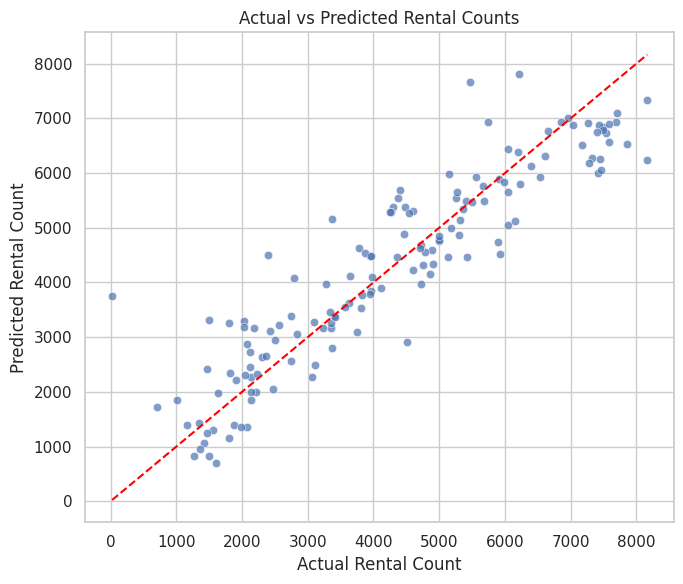

In [21]:
# 실제값과 예측값 산점도
plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=multiple_pred,
    alpha=0.7
)

# 실제값과 예측값이 동일한 기준선
min_value = min(y_test.min(), multiple_pred.min())
max_value = max(y_test.max(), multiple_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted Rental Counts")
plt.xlabel("Actual Rental Count")
plt.ylabel("Predicted Rental Count")
plt.tight_layout()
plt.show()

## 3.12 수요 구간별 과소·과대 예측 확인

모델이 특정 수요 구간에서 반복적으로 과소 또는 과대 예측하는지 확인하기 위해 실제 대여량을 저수요, 중수요, 고수요 구간으로 구분한다.

수요 구간은 일별 대여량의 분포와 운영상 해석의 편의성을 고려하여 3,000대 이하를 저수요, 3,001~6,000대를 중수요, 6,000대 초과를 고수요로 구분하였다. 이는 절대적인 기준이 아니라 모델의 수요 수준별 예측 경향을 비교하기 위한 분석 기준이다.

예측 오차는 `예측값 - 실제값`으로 계산한다. 평균 예측 오차가 양수이면 과대 예측, 음수이면 과소 예측으로 해석한다.

In [22]:
# 실제값과 예측값 비교 데이터 생성
prediction_result = pd.DataFrame({
    "실제값": y_test,
    "예측값": multiple_pred
})

# 예측 오차 계산: 양수는 과대 예측, 음수는 과소 예측
prediction_result["예측오차"] = (
    prediction_result["예측값"]
    - prediction_result["실제값"]
)

# 실제 대여량을 기준으로 수요 구간 분류
prediction_result["수요구간"] = pd.cut(
    prediction_result["실제값"],
    bins=[0, 3000, 6000, np.inf],
    labels=[
        "저수요(3,000대 이하)",
        "중수요(3,001~6,000대)",
        "고수요(6,000대 초과)"
    ]
)

# 수요 구간별 평균 예측 오차 확인
demand_error = (
    prediction_result.groupby(
        "수요구간",
        observed=True
    )["예측오차"]
    .agg(["count", "mean"])
    .round(2)
)

display(demand_error)

,count,mean
수요구간,,
"저수요(3,000대 이하)",45,369.87
"중수요(3,001~6,000대)",69,72.22
"고수요(6,000대 초과)",33,-589.69


In [23]:
for demand_group, row in demand_error.iterrows():
    mean_error = row["mean"]

    if mean_error > 0:
        prediction_type = "과대 예측"
    elif mean_error < 0:
        prediction_type = "과소 예측"
    else:
        prediction_type = "예측 차이 없음"

    print(
        demand_group,
        ": 평균 예측 오차",
        round(mean_error, 2),
        "대 →",
        prediction_type
    )

저수요(3,000대 이하) : 평균 예측 오차 369.87 대 → 과대 예측
중수요(3,001~6,000대) : 평균 예측 오차 72.22 대 → 과대 예측
고수요(6,000대 초과) : 평균 예측 오차 -589.69 대 → 과소 예측


## 3.13 예측 경향 분석 결과

실제값과 예측값의 산점도에서 다수의 관측값이 대각선 주변에 분포하여 최종 모델이 일별 대여량의 전반적인 변화를 비교적 잘 예측하는 것으로 나타났다.

수요 구간별 평균 예측 오차를 확인한 결과, 저수요 구간에서는 실제 대여량보다 평균 약 370대를 높게 예측하는 과대 예측 경향이 나타났다.

중수요 구간에서는 평균 예측 오차가 약 72대로 비교적 작게 나타났으며, 실제 대여량과 예측 대여량의 차이가 다른 구간보다 크지 않았다.

반면 고수요 구간에서는 실제 대여량보다 평균 약 590대를 낮게 예측하는 과소 예측 경향이 나타났다.

따라서 모델을 운영 계획에 활용할 때 저수요 시기에는 필요한 자전거와 인력을 실제보다 많이 배치할 가능성이 있고, 고수요 시기에는 자전거와 운영 인력을 부족하게 배치할 가능성이 있다. 특히 고수요가 예상되는 날에는 모델의 예측값만 사용하기보다 추가적인 여유 자전거와 인력을 확보할 필요가 있다.

# 4단계. 결과 해석 및 보고서 작성

최종 다중선형회귀 모델의 회귀계수와 통계적 유의성을 확인한다.

회귀계수의 부호와 크기를 이용하여 각 환경 요인이 자전거 대여량에 미치는 영향을 해석하고, 분석 결과를 자전거 배치와 운영 인력 계획에 활용할 수 있는 인사이트로 연결한다.

## 4.1 회귀계수와 통계적 유의성 확인

`scikit-learn`으로 구축한 다중선형회귀 모델은 예측과 성능 평가에는 편리하지만 p-value를 제공하지 않는다.

따라서 회귀계수, p-value 및 95% 신뢰구간을 확인하기 위해 `statsmodels`의 OLS 회귀모델을 추가로 사용한다.

예측 성능 평가에 사용한 테스트 데이터가 회귀계수 계산에 포함되지 않도록, `statsmodels` 모델도 학습 데이터만 사용하여 구축한다.

In [24]:
import statsmodels.api as sm

# statsmodels 분석을 위한 자료형 변환
X_train_sm = X_train.astype(float)
y_train_sm = y_train.astype(float)

# statsmodels는 절편을 직접 추가
X_train_sm = sm.add_constant(X_train_sm)

# 다중선형회귀 모델 구축
ols_model = sm.OLS(
    y_train_sm,
    X_train_sm
).fit()

# 회귀분석 결과 출력
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     231.5
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          2.11e-202
Time:                        08:18:03   Log-Likelihood:                -4746.9
No. Observations:                 584   AIC:                             9518.
Df Residuals:                     572   BIC:                             9570.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1373.6272    257.829      5.328   

## 4.2 회귀계수와 p-value 정리

회귀분석 결과에서 회귀계수, p-value 및 95% 신뢰구간을 추출하여 표로 정리한다.

일반적으로 p-value가 0.05보다 작으면 해당 변수는 다른 변수의 영향을 통제한 상태에서도 대여량과 통계적으로 유의한 관계가 있다고 판단한다.

In [25]:
# 회귀계수, p-value, 신뢰구간 정리
coefficient_result = pd.DataFrame({
    "회귀계수": ols_model.params,
    "p-value": ols_model.pvalues,
    "신뢰구간_하한": ols_model.conf_int()[0],
    "신뢰구간_상한": ols_model.conf_int()[1]
})

# 통계적 유의성 표시
coefficient_result["유의성"] = np.where(
    coefficient_result["p-value"] < 0.05,
    "유의함",
    "유의하지 않음"
)

display(coefficient_result.round(4))

,회귀계수,p-value,신뢰구간_하한,신뢰구간_상한,유의성
const,1373.6272,0.0000,867.2204,1880.0340,유의함
temp,5243.0869,0.0000,4549.6016,5936.5721,유의함
hum,-1153.3362,0.0005,-1803.5221,-503.1504,유의함
windspeed,-2519.6219,0.0000,-3466.6341,-1572.6098,유의함
season_2,1159.5314,0.0000,901.8784,1417.1844,유의함
season_3,747.6594,0.0000,409.1543,1086.1645,유의함
season_4,1585.1377,0.0000,1367.4008,1802.8745,유의함
weathersit_2,-488.4393,0.0000,-668.0652,-308.8134,유의함
weathersit_3,-1747.9949,0.0000,-2190.4636,-1305.5261,유의함
holiday_1,-546.1371,0.0148,-984.8303,-107.4438,유의함


In [26]:
# 절편을 제외하고 통계적으로 유의한 변수 확인
significant_variables = coefficient_result.loc[
    (coefficient_result.index != "const")
    & (coefficient_result["p-value"] < 0.05)
].copy()

# 회귀계수의 절댓값 기준 정렬
significant_variables["계수절댓값"] = (
    significant_variables["회귀계수"].abs()
)

significant_variables = significant_variables.sort_values(
    "계수절댓값",
    ascending=False
)

display(
    significant_variables[
        ["회귀계수", "p-value", "유의성"]
    ].round(4)
)

,회귀계수,p-value,유의성
temp,5243.0869,0.0000,유의함
windspeed,-2519.6219,0.0000,유의함
yr_1,1991.7929,0.0000,유의함
weathersit_3,-1747.9949,0.0000,유의함
season_4,1585.1377,0.0000,유의함
season_2,1159.5314,0.0000,유의함
hum,-1153.3362,0.0005,유의함
season_3,747.6594,0.0000,유의함
holiday_1,-546.1371,0.0148,유의함
weathersit_2,-488.4393,0.0000,유의함


## 4.3 주요 회귀계수의 의미

연속형 변수의 회귀계수는 해당 변수가 1단위 증가할 때 예상되는 대여량의 변화를 의미한다.

다만 `temp`, `hum`, `windspeed`는 정규화된 변수이므로 원래 단위에 맞추거나 0.1 증가 기준으로 변환하여 해석한다.

범주형 변수의 회귀계수는 다른 조건이 동일할 때 해당 범주와 기준 범주의 예상 대여량 차이를 의미한다.

In [27]:
# 주요 변수의 회귀계수
temp_coef = ols_model.params["temp"]
hum_coef = ols_model.params["hum"]
windspeed_coef = ols_model.params["windspeed"]

print("temp 회귀계수:", round(temp_coef, 2))
print("hum 회귀계수:", round(hum_coef, 2))
print("windspeed 회귀계수:", round(windspeed_coef, 2))

# 정규화된 값이 0.1 증가할 때 대여량 변화
print(
    "\ntemp가 0.1 증가할 때:",
    round(temp_coef * 0.1, 2),
    "대"
)

print(
    "hum이 0.1 증가할 때:",
    round(hum_coef * 0.1, 2),
    "대"
)

print(
    "windspeed가 0.1 증가할 때:",
    round(windspeed_coef * 0.1, 2),
    "대"
)

# 실제 기온 1°C 상승 효과
print(
    "\n기온이 1°C 상승할 때:",
    round(temp_coef / 41, 2),
    "대"
)

temp 회귀계수: 5243.09
hum 회귀계수: -1153.34
windspeed 회귀계수: -2519.62

temp가 0.1 증가할 때: 524.31 대
hum이 0.1 증가할 때: -115.33 대
windspeed가 0.1 증가할 때: -251.96 대

기온이 1°C 상승할 때: 127.88 대


### 연속형 변수 해석

다른 조건이 동일할 때 정규화된 기온 `temp`가 0.1 증가하면 일별 대여량은 평균적으로 약 524대 증가하는 것으로 나타났다. `temp`는 실제 섭씨온도를 41로 나눈 값이므로, 실제 기온이 1°C 상승하면 일별 대여량은 평균적으로 약 128대 증가하는 것으로 해석할 수 있다.

정규화된 습도 `hum`이 0.1, 즉 습도가 10% 증가하면 일별 대여량은 평균적으로 약 115대 감소하는 것으로 나타났다.

정규화된 풍속 `windspeed`의 단위가 0.1 증가하면 일별 대여량은 평균적으로 약 252대 감소하는 것으로 나타났다.

따라서 기온은 대여량과 양의 관계가 있으며, 습도와 풍속은 대여량과 음의 관계가 있는 것으로 해석할 수 있다.

## 4.4 범주형 변수의 회귀계수 해석

원-핫 인코딩에서 제외한 기준 범주는 다음과 같다.

- 계절 기준: 봄(`season=1`)
- 날씨 기준: 맑은 날(`weathersit=1`)
- 공휴일 기준: 공휴일이 아닌 날(`holiday=0`)
- 근무일 기준: 근무일이 아닌 날(`workingday=0`)
- 연도 기준: 2011년(`yr=0`)

각 더미변수의 회귀계수는 다른 조건이 동일할 때 기준 범주와 비교한 예상 대여량의 차이를 의미한다.

In [28]:
# 범주형 변수의 회귀계수와 p-value 확인
categorical_result = coefficient_result.loc[[
    "season_2",
    "season_3",
    "season_4",
    "weathersit_2",
    "weathersit_3",
    "holiday_1",
    "workingday_1",
    "yr_1"
]]

display(categorical_result.round(4))

,회귀계수,p-value,신뢰구간_하한,신뢰구간_상한,유의성
season_2,1159.5314,0.0000,901.8784,1417.1844,유의함
season_3,747.6594,0.0000,409.1543,1086.1645,유의함
season_4,1585.1377,0.0000,1367.4008,1802.8745,유의함
weathersit_2,-488.4393,0.0000,-668.0652,-308.8134,유의함
weathersit_3,-1747.9949,0.0000,-2190.4636,-1305.5261,유의함
holiday_1,-546.1371,0.0148,-984.8303,-107.4438,유의함
workingday_1,152.0775,0.0444,3.8100,300.3450,유의함
yr_1,1991.7929,0.0000,1854.5007,2129.0852,유의함


### 범주형 변수 해석

다른 조건이 동일할 때 안개가 끼거나 흐린 날(`weathersit_2`)에는 맑은 날보다 일별 대여량이 평균적으로 약 488대 감소하였다.

약한 비나 눈이 오는 날(`weathersit_3`)에는 맑은 날보다 일별 대여량이 평균적으로 약 1,748대 감소하였다. 따라서 날씨가 악화될수록 자전거 이용 수요가 크게 감소하는 것으로 해석할 수 있다.

공휴일(`holiday_1`)에는 공휴일이 아닌 날보다 일별 대여량이 평균적으로 약 546대 감소하였다.

근무일(`workingday_1`)에는 근무일이 아닌 날보다 일별 대여량이 평균적으로 약 152대 증가하였다.

2012년(`yr_1`)에는 다른 조건이 동일할 때 2011년보다 일별 대여량이 평균적으로 약 1,992대 많았다. 이는 공유 자전거 서비스의 이용자 증가 또는 서비스 성장에 따른 연도 효과가 반영된 결과로 볼 수 있다.

## 4.5 통계적으로 유의한 변수

일반적으로 p-value가 0.05보다 작으면 해당 변수가 일별 대여량과 통계적으로 유의한 관계가 있다고 판단한다.

다만 p-value는 관계의 존재 여부를 판단하는 기준이며, 실제 운영상 영향의 크기는 회귀계수와 변수의 단위를 함께 고려하여 판단해야 한다.

In [29]:
# 변수별 p-value와 유의성 출력
for variable in coefficient_result.index:
    if variable == "const":
        continue

    p_value = coefficient_result.loc[variable, "p-value"]

    if p_value < 0.05:
        result = "통계적으로 유의함"
    else:
        result = "통계적으로 유의하지 않음"

    print(
        variable,
        ": p-value =",
        round(p_value, 4),
        "→",
        result
    )

temp : p-value = 0.0 → 통계적으로 유의함
hum : p-value = 0.0005 → 통계적으로 유의함
windspeed : p-value = 0.0 → 통계적으로 유의함
season_2 : p-value = 0.0 → 통계적으로 유의함
season_3 : p-value = 0.0 → 통계적으로 유의함
season_4 : p-value = 0.0 → 통계적으로 유의함
weathersit_2 : p-value = 0.0 → 통계적으로 유의함
weathersit_3 : p-value = 0.0 → 통계적으로 유의함
holiday_1 : p-value = 0.0148 → 통계적으로 유의함
workingday_1 : p-value = 0.0444 → 통계적으로 유의함
yr_1 : p-value = 0.0 → 통계적으로 유의함


### 통계적 유의성 분석 결과

유의수준 5%를 기준으로 기온, 습도, 풍속, 계절, 날씨 상태, 공휴일 여부, 근무일 여부 및 연도 변수가 일별 대여량과 통계적으로 유의한 관계를 보였다.

특히 기온은 대여량 증가와 관련이 있었으며, 흐리거나 비·눈이 오는 날에는 맑은 날보다 대여량이 감소하는 것으로 나타났다.

또한 2012년의 대여량이 2011년보다 유의하게 높게 나타나 날씨 및 계절 요인 외에도 서비스 성장과 시간 흐름에 따른 변화가 존재할 가능성을 확인하였다.

다만 통계적으로 유의하다는 결과가 해당 변수가 대여량 변화의 직접적인 원인이라는 것을 의미하지는 않는다.

## 4.6 표준화 회귀계수를 이용한 영향력 비교

원래 회귀계수는 각 변수가 실제 대여량에 미치는 변화를 해석하는 데 유용하다.

그러나 연속형 변수와 범주형 더미변수는 단위와 분포가 다르므로 원래 회귀계수의 절댓값만으로 영향력을 직접 비교하기 어렵다.

따라서 독립변수와 종속변수를 평균 0, 표준편차 1이 되도록 표준화한 후 표준화 회귀계수를 계산한다.

표준화 회귀계수의 절댓값이 클수록 다른 변수의 조건이 동일할 때 해당 변수의 상대적인 영향력이 큰 것으로 해석한다.

In [30]:
from sklearn.preprocessing import StandardScaler

# 독립변수와 종속변수를 위한 표준화 도구
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# 학습 데이터만 이용하여 표준화 기준 계산
X_train_scaled = x_scaler.fit_transform(X_train)

y_train_scaled = y_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

# 표준화된 데이터로 다중선형회귀 모델 구축
standardized_model = LinearRegression()

standardized_model.fit(
    X_train_scaled,
    y_train_scaled
)

# 표준화 회귀계수 정리
standardized_coefficients = pd.DataFrame({
    "변수": X_train.columns,
    "표준화 회귀계수": standardized_model.coef_
})

# 영향력 비교를 위한 절댓값 계산
standardized_coefficients["계수 절댓값"] = (
    standardized_coefficients["표준화 회귀계수"].abs()
)

# 절댓값이 큰 순서로 정렬
standardized_coefficients = (
    standardized_coefficients
    .sort_values(
        "계수 절댓값",
        ascending=False
    )
    .reset_index(drop=True)
)

display(standardized_coefficients.round(4))

,변수,표준화 회귀계수,계수 절댓값
0,yr_1,0.5199,0.5199
1,temp,0.4968,0.4968
2,season_4,0.3543,0.3543
3,season_2,0.2652,0.2652
4,season_3,0.1710,0.1710
5,weathersit_3,-0.1578,0.1578
6,weathersit_2,-0.1209,0.1209
7,windspeed,-0.1018,0.1018
8,hum,-0.0856,0.0856
9,holiday_1,-0.0451,0.0451


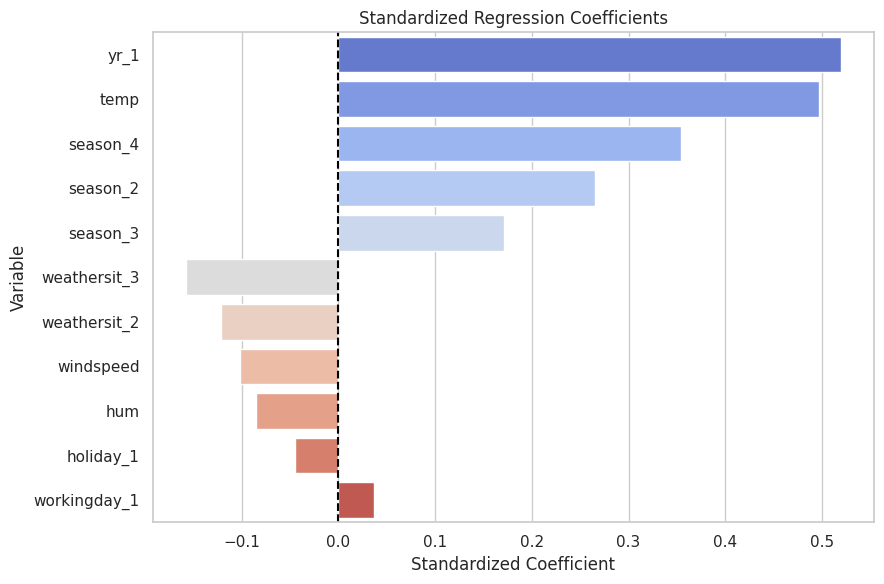

In [31]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=standardized_coefficients,
    x="표준화 회귀계수",
    y="변수",
    hue="변수",
    palette="coolwarm",
    legend=False
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--"
)

plt.title("Standardized Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 영향력이 큰 변수 분석 결과

변수들의 상대적인 영향력을 비교하기 위해 독립변수와 종속변수를 평균 0, 표준편차 1로 표준화한 후 표준화 회귀계수를 확인하였다.

표준화 회귀계수의 절댓값을 기준으로 영향력이 큰 변수는 연도 `yr_1`, 기온 `temp`, 계절 변수, 날씨 상태 변수 순으로 나타났다.

`yr_1`의 표준화 회귀계수는 약 0.520으로 가장 크게 나타났다. 이는 다른 조건이 동일할 때 2012년의 대여량이 2011년보다 크게 증가했으며, 서비스 성장 또는 시간 흐름에 따른 변화가 대여량에 큰 영향을 주었음을 의미한다. 다만 본 데이터는 2011년과 2012년의 두 연도만 포함하므로, 이러한 차이가 지속적인 성장 추세를 의미한다고 단정하기는 어렵다. 서비스 성장 외에도 자전거 공급 규모, 운영 정책, 이용자 인지도 등 관측되지 않은 요인이 연도별 차이에 영향을 주었을 가능성이 있으므로 해석에 주의가 필요하다.

`temp`의 표준화 회귀계수는 약 0.497로 두 번째로 크게 나타났다. 기온이 높아질수록 자전거 대여량이 증가하는 경향이 있으며, 운영팀이 단기적인 수요를 판단할 때 중요하게 확인해야 하는 변수로 볼 수 있다.

계절 변수 중에서는 `season_4`, `season_2`, `season_3` 순으로 표준화 회귀계수의 절댓값이 크게 나타났다. 이는 기온과 날씨를 통제한 이후에도 계절별 이용 패턴의 차이가 존재함을 의미한다.

날씨 상태에서는 `weathersit_3`의 표준화 회귀계수가 약 -0.158로 나타났다. 이는 약한 비나 눈이 오는 날에 대여량이 감소하는 방향으로 영향을 미친다는 것을 의미한다.

풍속과 습도의 표준화 회귀계수는 각각 약 -0.102와 -0.086으로 나타나 대여량을 감소시키는 방향의 관계를 보였으나, 연도와 기온에 비해 상대적인 영향력은 작았다.

p-value를 함께 확인한 결과 주요 변수들은 유의수준 5%에서 통계적으로 유의하였다.

따라서 통계적 유의성과 표준화 회귀계수의 크기를 함께 고려할 때, 대여량에 상대적으로 큰 영향을 미치는 핵심 변수는 연도, 기온, 계절 및 날씨 상태로 판단하였다.

## 4.7 운영 의사결정 인사이트

### 인사이트 1. 기온과 날씨에 따른 자전거 및 인력 사전 배치

기온이 상승할수록 대여량이 증가하고, 비나 눈이 오는 날에는 대여량이 크게 감소하는 것으로 나타났다.

따라서 기온이 높고 날씨가 맑을 것으로 예상되는 날에는 주요 대여소에 자전거를 미리 추가 배치하고 재배치 인력을 확대할 필요가 있다. 반대로 비나 눈이 예상되는 날에는 현장 재배치 인력을 줄이고 자전거 점검과 정비 업무의 비중을 높일 수 있다.

### 인사이트 2. 고수요 구간의 과소 예측을 고려한 안전 재고 확보

예측 경향을 확인한 결과, 실제 대여량이 6,000대를 초과하는 고수요 구간에서는 모델이 평균적으로 약 590대를 과소 예측하는 경향이 나타났다.

따라서 고수요가 예상되는 날에는 모델의 예측값만큼만 자전거와 인력을 준비하기보다 추가적인 여유 자전거와 운영 인력을 확보하는 것이 필요하다.

### 인사이트 3. 서비스 성장에 따른 중장기 운영 규모 확대

2012년은 다른 조건이 동일할 때 2011년보다 일별 대여량이 높은 것으로 나타났다.

이는 공유 자전거 서비스의 이용 규모가 증가했을 가능성을 보여준다. 따라서 단기적인 날씨 대응뿐만 아니라 서비스 성장 추세를 고려하여 자전거 보유량, 대여소 규모 및 운영 인력을 단계적으로 확대할 필요가 있다.

## 4.8 분석의 한계

본 데이터는 2011년부터 2012년까지 미국 워싱턴 D.C.에서 수집된 자료이므로 현재 시점이나 다른 지역의 자전거 수요에 결과를 그대로 적용하기 어렵다.

이번 모델은 기온과 대여량 등의 관계가 선형이라고 가정하므로 복잡한 비선형 관계를 충분히 반영하지 못할 수 있다.

또한 지역 행사, 강수량, 대여소별 위치와 같은 변수가 포함되지 않아 특정 날짜의 급격한 수요 변화를 설명하는 데 한계가 있다.

데이터를 무작위로 학습·테스트 세트로 분리하였기 때문에 시간의 흐름을 고려한 미래 예측과는 차이가 있다. 향후 분석에서는 과거 데이터로 학습하고 이후 기간을 테스트하는 시간 순서 기반 평가를 고려할 수 있다.

## 4.9 최종 결론

본 분석에서는 날씨, 계절 및 근무일 등의 환경 요인을 이용하여 일별 공유 자전거 대여량을 예측하는 다중선형회귀 모델을 구축하였다.

다중선형회귀 모델은 기온만 사용한 단순선형회귀 모델보다 높은 R²와 낮은 RMSE 및 MAE를 보여, 여러 환경 요인을 함께 사용하는 것이 대여량 예측에 효과적임을 확인하였다.

회귀계수와 p-value를 확인한 결과 기온, 습도, 풍속, 계절, 날씨 상태 및 연도 등의 변수가 일별 대여량과 유의한 관계를 보였다. 특히 기온이 높을수록 대여량이 증가하고, 비나 눈이 오는 날에는 대여량이 크게 감소하는 경향이 나타났다.

운영 관점에서는 기온이 높고 날씨가 맑은 날에 자전거와 재배치 인력을 확대하고, 고수요 구간에서 발생하는 과소 예측을 고려하여 추가적인 여유 자전거와 인력을 확보할 필요가 있다.

따라서 본 모델은 일별 수요를 완벽하게 예측하는 도구라기보다, 날씨와 계절 정보를 바탕으로 자전거 배치 및 인력 운영 계획을 지원하는 기초 의사결정 도구로 활용할 수 있다.

## 4.10 최종 분석 요약

In [32]:
# 최종 모델 성능과 주요 정보를 요약
final_summary = pd.DataFrame({
    "항목": [
        "최종 모델",
        "학습 데이터 수",
        "테스트 데이터 수",
        "독립변수 수",
        "테스트 R²",
        "테스트 RMSE",
        "테스트 MAE"
    ],
    "결과": [
        "다중선형회귀",
        len(X_train),
        len(X_test),
        X_train.shape[1],
        round(multiple_r2, 3),
        round(multiple_rmse, 2),
        round(multiple_mae, 2)
    ]
})

display(final_summary)

,항목,결과
0,최종 모델,다중선형회귀
1,학습 데이터 수,584
2,테스트 데이터 수,147
3,독립변수 수,11
4,테스트 R²,0.835
5,테스트 RMSE,812.23
6,테스트 MAE,609.58
